# Level 3 – Signal Properties

Signal properties describe the characteristics of a signal. Unlike Level 1 and Level 2, they do not primarily modify the signal. Instead, they help us measure, analyze, compare, and understand signals.

# Level 3.1 – Amplitude

### Theory
Amplitude represents the magnitude (strength) of a signal at any instant of time. Higher amplitude usually corresponds to stronger sound, brighter pixels, or stronger sensor measurements.

### Why Do We Need Amplitude?
* Measure signal strength
* Detect peaks
* Normalize signals
* Prevent clipping

---

## Mathematical Equation

### Equation T
$$A = \max(|x[n]|)$$

Where:
* $x[n]$ is the discrete-time input signal
* $|x[n]|$ is the absolute magnitude of the signal at index $n$
* $A$ is the peak amplitude



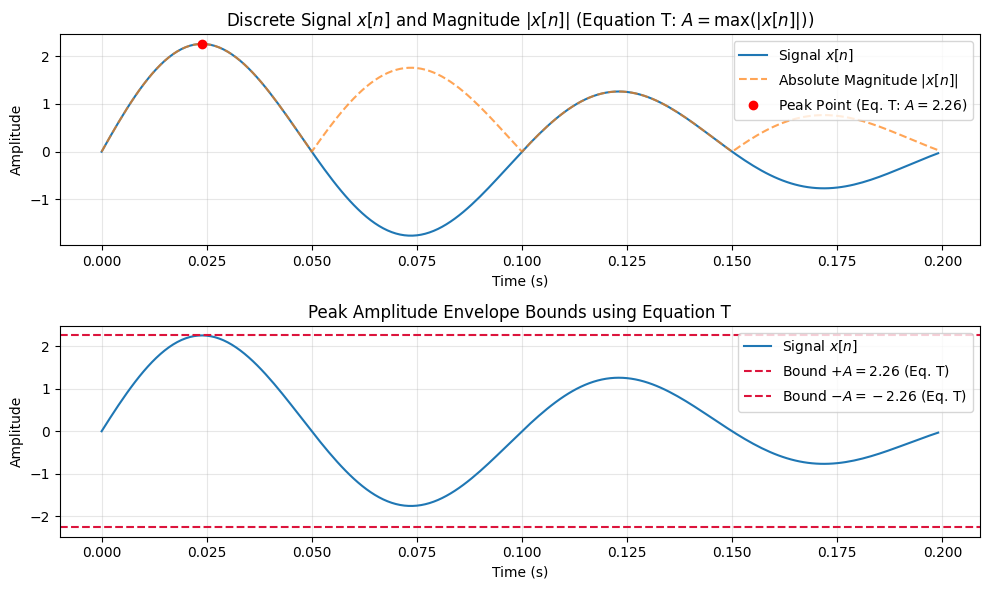

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Discrete-Time Signal x[n]
fs = 1000  # Sampling frequency (Hz)
N = 200  # Total sample count
n = np.arange(N)  # Sample index n
t = n / fs  # Continuous time mapping

# Generate a signal with a decaying amplitude envelope
envelope = 2.5 - 2.0 * (n / N)
x = envelope * np.sin(2 * np.pi * 10 * t)

# 2. Implement Equation T: Peak Amplitude Extraction
# Equation T: A = max(|x[n]|)
abs_x = np.abs(x)  # Absolute magnitude |x[n]|
A = np.max(abs_x)  # Peak amplitude calculated via Equation T
n_peak = np.argmax(abs_x)  # Sample index of peak
t_peak = t[n_peak]

# 3. Visualizing Signal & Peak Bounds
plt.figure(figsize=(10, 6))

# Subplot 1: Plot Signal and Absolute Magnitude
plt.subplot(2, 1, 1)
plt.plot(t, x, label=r"Signal $x[n]$", color="tab:blue", linewidth=1.5)
plt.plot(
    t,
    abs_x,
    label=r"Absolute Magnitude $|x[n]|$",
    color="tab:orange",
    linestyle="--",
    alpha=0.7,
)
plt.plot(t_peak, A, "ro", label=f"Peak Point (Eq. T: $A = {A:.2f}$)")
plt.title(
    r"Discrete Signal $x[n]$ and Magnitude $|x[n]|$ (Equation T: $A = \max(|x[n]|)$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Plot Envelope & Peak Bounds (+A, -A)
plt.subplot(2, 1, 2)
plt.plot(t, x, label=r"Signal $x[n]$", color="tab:blue", linewidth=1.5)
plt.axhline(
    A,
    color="crimson",
    linestyle="--",
    label=f"Bound $+A = {A:.2f}$ (Eq. T)",
)
plt.axhline(
    -A,
    color="crimson",
    linestyle="--",
    label=f"Bound $-A = -{A:.2f}$ (Eq. T)",
)
plt.title(r"Peak Amplitude Envelope Bounds using Equation T")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Level 3.2 – Energy

### Theory
Energy measures the total amount of signal content over its entire duration. Signals that exist only for a limited time (pulse, clap, radar pulse) are usually analyzed using energy.

### Why Do We Need Energy?
* Compare finite signals
* Radar
* Echo detection
* Pattern matching

---

## Mathematical Equation

### Equation U
$$E = \sum_{n=-\infty}^{\infty} |x[n]|^2$$

Where:
* $x[n]$ is the discrete-time input signal
* $|x[n]|^2$ is the instantaneous power at sample index $n$
* $E$ is the total signal energy over all time

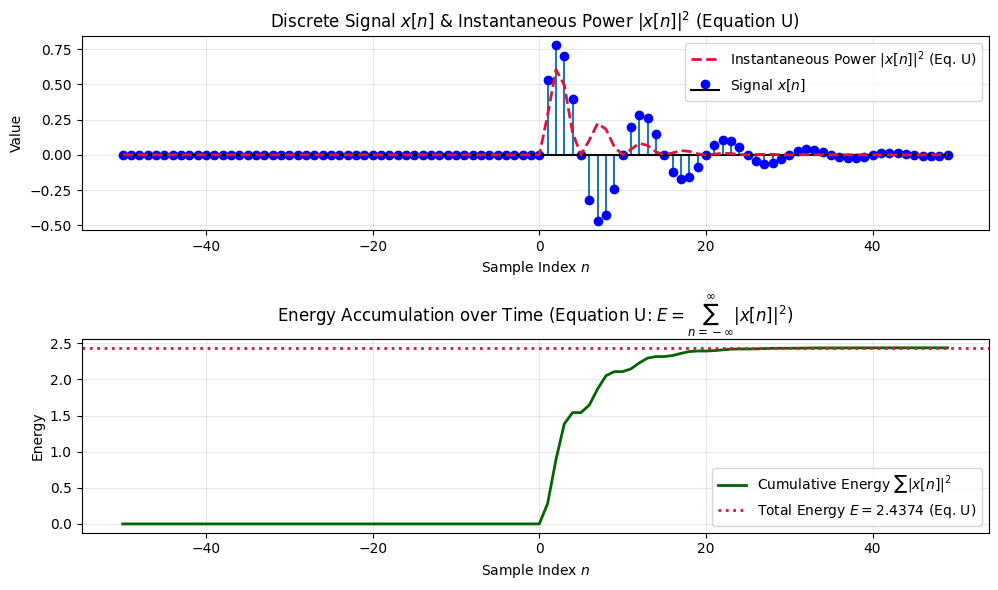

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Finite-Duration Discrete-Time Pulse Signal x[n]
N = 100  # Total sample count
n = np.arange(-N // 2, N // 2)  # Sample indices from -50 to 49

# Generate a decaying exponential pulse signal (finite energy)
x = np.where(n >= 0, np.exp(-0.1 * n) * np.sin(2 * np.pi * 0.1 * n), 0.0)

# 2. Implement Equation U: Total Energy Calculation
# Equation U: E = sum(|x[n]|^2)
instantaneous_power = np.abs(x) ** 2  # |x[n]|^2 term in Equation U
E = np.sum(instantaneous_power)  # Total Energy E via Equation U

# Cumulative energy over time to illustrate the summation process
cumulative_energy = np.cumsum(instantaneous_power)

# 3. Visualizing Signal Energy (Equation U)
plt.figure(figsize=(10, 6))

# Subplot 1: Signal x[n] and Instantaneous Power |x[n]|^2
plt.subplot(2, 1, 1)
plt.stem(
    n,
    x,
    linefmt="tab:blue",
    markerfmt="bo",
    basefmt="k-",
    label=r"Signal $x[n]$",
)
plt.plot(
    n,
    instantaneous_power,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=r"Instantaneous Power $|x[n]|^2$ (Eq. U)",
)
plt.title(
    r"Discrete Signal $x[n]$ & Instantaneous Power $|x[n]|^2$ (Equation U)"
)
plt.xlabel("Sample Index $n$")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Accumulation of Total Energy E over samples
plt.subplot(2, 1, 2)
plt.plot(
    n,
    cumulative_energy,
    color="darkgreen",
    linewidth=2,
    label=r"Cumulative Energy $\sum |x[n]|^2$",
)
plt.axhline(
    E,
    color="crimson",
    linestyle=":",
    linewidth=2,
    label=f"Total Energy $E = {E:.4f}$ (Eq. U)",
)
plt.title(
    r"Energy Accumulation over Time (Equation U: $E = \sum_{n=-\infty}^{\infty} |x[n]|^2$)"
)
plt.xlabel("Sample Index $n$")
plt.ylabel("Energy")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Level 3.3 – Power

### Theory
Power measures the average energy per sample. Periodic signals (speech, music, communication signals) are generally characterized by power rather than total energy.

### Why Do We Need Power?
* Communication systems
* Audio engineering
* Wireless transmission

---

## Mathematical Equation

### Equation V
$$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2$$

Where:
* $x[n]$ is the discrete-time input signal
* $|x[n]|^2$ is the instantaneous energy at sample index $n$
* $N$ is the total number of samples
* $P$ is the average power per sample

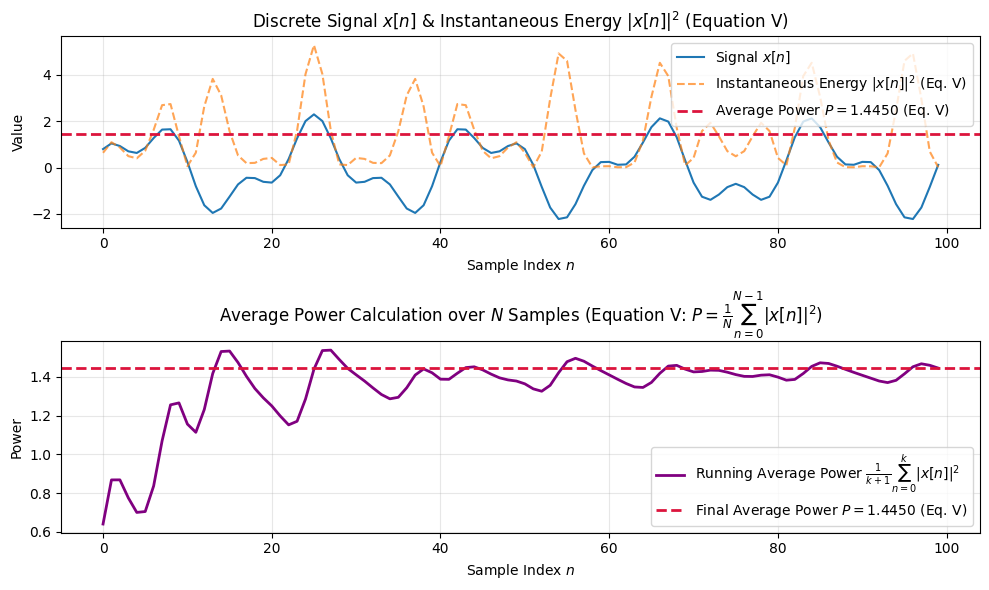

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Discrete-Time Signal x[n] (Periodic/Ongoing signal)
N = 100  # Total number of samples N
n = np.arange(N)  # Sample indices n = 0, 1, ..., N-1

# Generate a discrete signal with multiple frequency components
x = 1.5 * np.sin(2 * np.pi * 0.05 * n) + 0.8 * np.cos(2 * np.pi * 0.12 * n)

# 2. Implement Equation V: Average Power Calculation
# Equation V: P = (1/N) * sum(|x[n]|^2)
instantaneous_energy = np.abs(x) ** 2  # |x[n]|^2 term in Equation V
P = (1 / N) * np.sum(
    instantaneous_energy
)  # Average Power P calculated via Equation V

# Running average power over N samples to demonstrate convergence to P
running_average_power = np.cumsum(instantaneous_energy) / (n + 1)

# 3. Visualizing Signal Power (Equation V)
plt.figure(figsize=(10, 6))

# Subplot 1: Signal x[n] and Instantaneous Energy |x[n]|^2
plt.subplot(2, 1, 1)
plt.plot(t := n, x, label=r"Signal $x[n]$", color="tab:blue", linewidth=1.5)
plt.plot(
    t,
    instantaneous_energy,
    label=r"Instantaneous Energy $|x[n]|^2$ (Eq. V)",
    color="tab:orange",
    linestyle="--",
    alpha=0.7,
)
plt.axhline(
    P,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Average Power $P = {P:.4f}$ (Eq. V)",
)
plt.title(
    r"Discrete Signal $x[n]$ & Instantaneous Energy $|x[n]|^2$ (Equation V)"
)
plt.xlabel("Sample Index $n$")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Running Average Converging to Total Average Power P
plt.subplot(2, 1, 2)
plt.plot(
    n,
    running_average_power,
    color="purple",
    linewidth=2,
    label=r"Running Average Power $\frac{1}{k+1}\sum_{n=0}^{k} |x[n]|^2$",
)
plt.axhline(
    P,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Final Average Power $P = {P:.4f}$ (Eq. V)",
)
plt.title(
    r"Average Power Calculation over $N$ Samples (Equation V: $P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2$)"
)
plt.xlabel("Sample Index $n$")
plt.ylabel("Power")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Level 3.4 – Frequency

### Theory
Frequency describes how rapidly a signal repeats over time. Higher frequency means faster oscillations and shorter repeating periods.

### Why Do We Need Frequency?
* Audio analysis
* Musical notes
* Vibration analysis
* Communications

---

## Mathematical Equation

### Equation W
$$f = \frac{1}{T}$$

Where:
* $T$ is the period (time duration of one complete cycle)
* $f$ is the fundamental frequency ($\text{Hz}$)

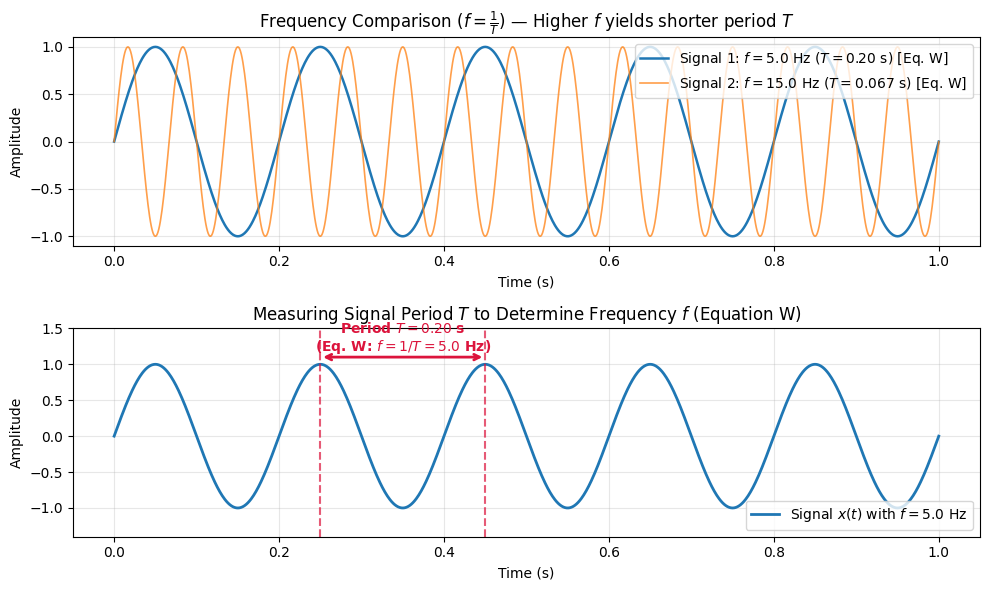

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Signal Parameters & Equation W Definition
f_target = 5.0  # Target frequency f = 5 Hz
T = 1 / f_target  # Equation W: T = 1 / f (Period T = 0.2 seconds)

fs = 1000  # High sampling frequency to illustrate continuous wave
t_max = 1.0  # Total time duration (seconds)
t = np.linspace(0, t_max, int(fs * t_max))

# Generate sinusoidal signal x(t) = sin(2 * pi * f * t)
x = np.sin(2 * np.pi * f_target * t)

# Calculate frequency from period using Equation W
f_calc = 1 / T  # Equation W: f = 1 / T

# 2. Visualizing Frequency & Period (Equation W)
plt.figure(figsize=(10, 6))

# Subplot 1: Low Frequency vs High Frequency comparison
f_high = 15.0
T_high = 1 / f_high  # Equation W for higher frequency
x_high = np.sin(2 * np.pi * f_high * t)

plt.subplot(2, 1, 1)
plt.plot(
    t,
    x,
    label=f"Signal 1: $f = {f_calc:.1f}$ Hz ($T = {T:.2f}$ s) [Eq. W]",
    color="tab:blue",
    linewidth=1.8,
)
plt.plot(
    t,
    x_high,
    label=f"Signal 2: $f = {f_high:.1f}$ Hz ($T = {T_high:.3f}$ s) [Eq. W]",
    color="tab:orange",
    linewidth=1.2,
    alpha=0.75,
)
plt.title(
    r"Frequency Comparison ($f = \frac{1}{T}$) — Higher $f$ yields shorter period $T$"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Detailed Period Annotation on Signal 1
plt.subplot(2, 1, 2)
plt.plot(
    t,
    x,
    label=f"Signal $x(t)$ with $f = {f_calc:.1f}$ Hz",
    color="tab:blue",
    linewidth=2,
)

# Highlight one complete cycle / period T
t_start_cycle = 0.25  # A peak point
t_end_cycle = t_start_cycle + T

plt.axvline(t_start_cycle, color="crimson", linestyle="--", alpha=0.7)
plt.axvline(t_end_cycle, color="crimson", linestyle="--", alpha=0.7)

# Double-headed arrow depicting Period T
plt.annotate(
    "",
    xy=(t_start_cycle, 1.1),
    xytext=(t_end_cycle, 1.1),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=2),
)
plt.text(
    t_start_cycle + T / 2,
    1.18,
    f"Period $T = {T:.2f}$ s\n(Eq. W: $f = 1/T = {f_calc:.1f}$ Hz)",
    color="crimson",
    ha="center",
    fontweight="bold",
)

plt.ylim(-1.4, 1.5)
plt.title(r"Measuring Signal Period $T$ to Determine Frequency $f$ (Equation W)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Level 3.5 – Phase

### Theory
Phase describes the relative position of one waveform with respect to another. Two signals may have identical frequencies but begin at different times or start at different points in their cycle.

### Why Do We Need Phase?
* Beamforming
* Radar
* Image reconstruction
* Communications

---

## Mathematical Equation

### Equation X
$$x(t) = A \sin(2\pi f t + \phi)$$

Where:
* $A$ is the peak amplitude
* $f$ is the frequency ($\text{Hz}$)
* $t$ is continuous time ($\text{seconds}$)
* $\phi$ is the phase angle ($\text{radians}$)

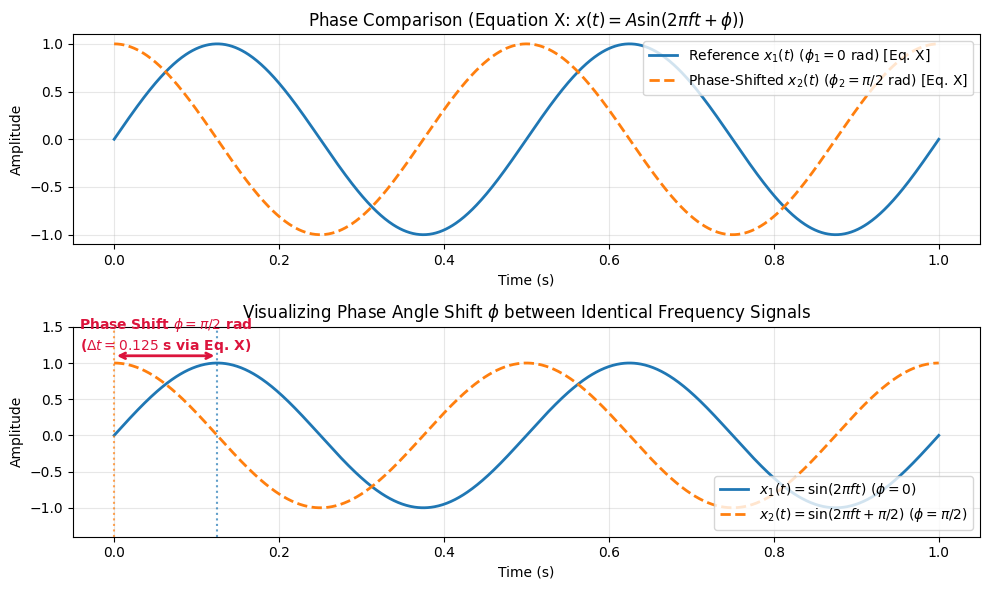

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Signal Parameters & Equation X Definition
A = 1.0  # Peak amplitude
f = 2.0  # Frequency in Hz
phi1 = 0.0  # Reference phase angle phi = 0 radians (Equation X)
phi2 = np.pi / 2  # Phase shift phi = pi/2 radians (90 deg) (Equation X)

fs = 1000  # Sampling frequency (Hz)
t_max = 1.0  # Total time duration (seconds)
t = np.linspace(0, t_max, int(fs * t_max))

# 2. Implement Equation X: Waveform Generation with Phase Shifts
# Equation X: x(t) = A * sin(2 * pi * f * t + phi)
x1 = A * np.sin(2 * np.pi * f * t + phi1)  # Reference signal (phi1 = 0)
x2 = A * np.sin(
    2 * np.pi * f * t + phi2
)  # Phase-shifted signal (phi2 = pi/2)

# Calculate equivalent time shift delta_t = phi / (2 * pi * f)
delta_t = phi2 / (2 * np.pi * f)

# 3. Visualizing Phase Shifts (Equation X)
plt.figure(figsize=(10, 6))

# Subplot 1: Comparing Reference Signal vs Phase-Shifted Signal
plt.subplot(2, 1, 1)
plt.plot(
    t,
    x1,
    label=r"Reference $x_1(t)$ ($\phi_1 = 0$ rad) [Eq. X]",
    color="tab:blue",
    linewidth=2,
)
plt.plot(
    t,
    x2,
    label=r"Phase-Shifted $x_2(t)$ ($\phi_2 = \pi/2$ rad) [Eq. X]",
    color="tab:orange",
    linewidth=2,
    linestyle="--",
)
plt.title(
    r"Phase Comparison (Equation X: $x(t) = A \sin(2\pi f t + \phi)$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Annotating the Time Shift corresponding to Phase Angle phi
plt.subplot(2, 1, 2)
plt.plot(
    t,
    x1,
    label=r"$x_1(t) = \sin(2\pi f t)$ ($\phi = 0$)",
    color="tab:blue",
    linewidth=2,
)
plt.plot(
    t,
    x2,
    label=r"$x_2(t) = \sin(2\pi f t + \pi/2)$ ($\phi = \pi/2$)",
    color="tab:orange",
    linewidth=2,
    linestyle="--",
)

# Annotate peak locations to visually demonstrate phase angle shift
t_peak1 = 1 / (4 * f)  # Peak of x1(t) at 1/(4f)
t_peak2 = t_peak1 - delta_t  # Peak of x2(t) shifted earlier by delta_t

plt.axvline(t_peak1, color="tab:blue", linestyle=":", alpha=0.7)
plt.axvline(t_peak2, color="tab:orange", linestyle=":", alpha=0.7)

# Double-headed arrow showing phase delay / time shift
plt.annotate(
    "",
    xy=(t_peak2, 1.1),
    xytext=(t_peak1, 1.1),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=2),
)
plt.text(
    (t_peak1 + t_peak2) / 2,
    1.18,
    f"Phase Shift $\\phi = \\pi/2$ rad\n($\\Delta t = {delta_t:.3f}$ s via Eq. X)",
    color="crimson",
    ha="center",
    fontweight="bold",
)

plt.ylim(-1.4, 1.5)
plt.title(r"Visualizing Phase Angle Shift $\phi$ between Identical Frequency Signals")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Level 3.6 – Bandwidth

### Theory
Bandwidth represents the range of frequencies occupied by a signal. It determines how much data or information the signal can transmit over a communication channel.

### Why Do We Need Bandwidth?
* Channel capacity
* Filter design
* Wireless communication
* Audio compression

---

## Mathematical Equation

### Equation Y
$$BW = f_H - f_L$$

Where:
* $f_H$ is the highest frequency component of the signal
* $f_L$ is the lowest frequency component of the signal
* $BW$ is the bandwidth ($\text{Hz}$)

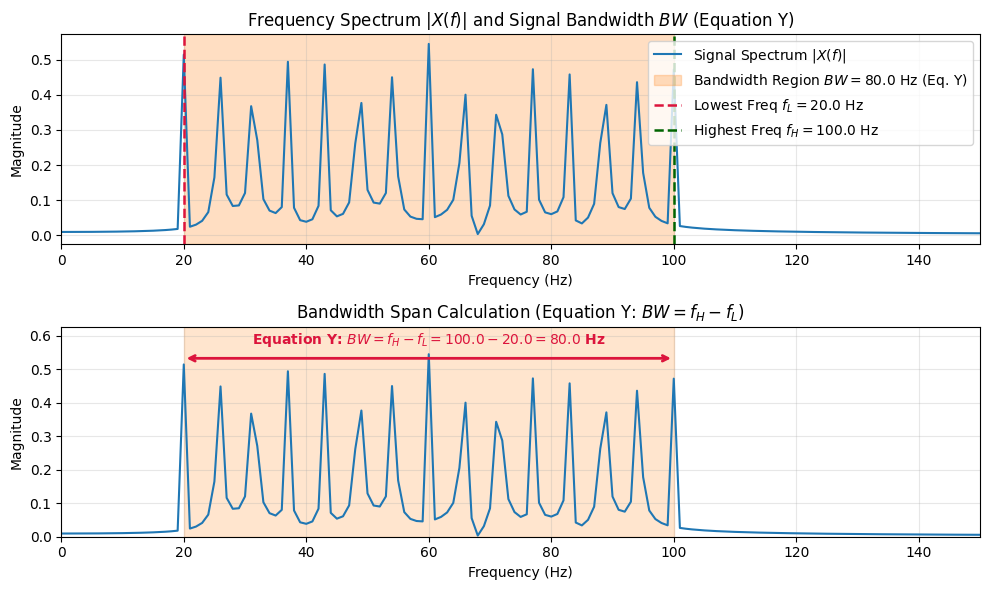

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Frequency Axis and Signal Spectrum Components
f_L = 20.0  # Lowest frequency component f_L = 20 Hz
f_H = 100.0  # Highest frequency component f_H = 100 Hz

# Equation Y: Bandwidth Calculation
BW = f_H - f_L  # BW = f_H - f_L = 80 Hz via Equation Y

# Time domain simulation parameters
fs = 1000  # Sampling frequency (Hz)
t = np.linspace(0, 1.0, fs, endpoint=False)
freqs = np.fft.rfftfreq(len(t), 1 / fs)

# Generate a band-limited multi-tone signal containing frequencies between f_L and f_H
signal = np.zeros_like(t)
np.random.seed(42)
tone_freqs = np.linspace(f_L, f_H, 15)
for f_tone in tone_freqs:
    phase = np.random.uniform(0, 2 * np.pi)
    signal += np.sin(2 * np.pi * f_tone * t + phase)

# Compute Frequency Spectrum (FFT Magnitude)
spectrum = np.abs(np.fft.rfft(signal)) / len(t)

# 2. Visualizing Bandwidth (Equation Y)
plt.figure(figsize=(10, 6))

# Subplot 1: Frequency Spectrum with Bandwidth Bounds (Equation Y)
plt.subplot(2, 1, 1)
plt.plot(
    freqs,
    spectrum,
    label=r"Signal Spectrum $|X(f)|$",
    color="tab:blue",
    linewidth=1.5,
)
plt.axvspan(
    f_L,
    f_H,
    color="tab:orange",
    alpha=0.25,
    label=f"Bandwidth Region $BW = {BW:.1f}$ Hz (Eq. Y)",
)

# Highlight f_L and f_H boundaries
plt.axvline(
    f_L,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label=f"Lowest Freq $f_L = {f_L:.1f}$ Hz",
)
plt.axvline(
    f_H,
    color="darkgreen",
    linestyle="--",
    linewidth=1.8,
    label=f"Highest Freq $f_H = {f_H:.1f}$ Hz",
)

plt.xlim(0, 150)
plt.title(
    r"Frequency Spectrum $|X(f)|$ and Signal Bandwidth $BW$ (Equation Y)"
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Annotating Bandwidth Span BW = f_H - f_L
plt.subplot(2, 1, 2)
plt.plot(freqs, spectrum, color="tab:blue", linewidth=1.5)
plt.axvspan(f_L, f_H, color="tab:orange", alpha=0.2)

# Annotate Equation Y: BW = f_H - f_L
y_max = np.max(spectrum) * 1.15
plt.annotate(
    "",
    xy=(f_L, y_max * 0.85),
    xytext=(f_H, y_max * 0.85),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=2),
)
plt.text(
    (f_L + f_H) / 2,
    y_max * 0.92,
    f"Equation Y: $BW = f_H - f_L = {f_H:.1f} - {f_L:.1f} = {BW:.1f}$ Hz",
    color="crimson",
    ha="center",
    fontweight="bold",
)

plt.xlim(0, 150)
plt.ylim(0, y_max)
plt.title(
    r"Bandwidth Span Calculation (Equation Y: $BW = f_H - f_L$)"
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Level 3.7 – Signal-to-Noise Ratio (SNR)

### Theory
SNR measures how strong the useful signal is compared to unwanted background noise. A higher SNR value indicates a cleaner, higher-quality signal.

### Why Do We Need SNR?
* Speech enhancement
* Image denoising
* Wireless communication
* Medical imaging

---

## Mathematical Equation

### Equation Z
$$\text{SNR}_{\text{dB}} = 10 \log_{10} \left( \frac{P_{\text{signal}}}{P_{\text{noise}}} \right)$$

Where:
* $P_{\text{signal}}$ is the power of the clean/desired signal
* $P_{\text{noise}}$ is the power of the unwanted noise signal
* $\text{SNR}_{\text{dB}}$ is the Signal-to-Noise Ratio expressed in decibels ($\text{dB}$)

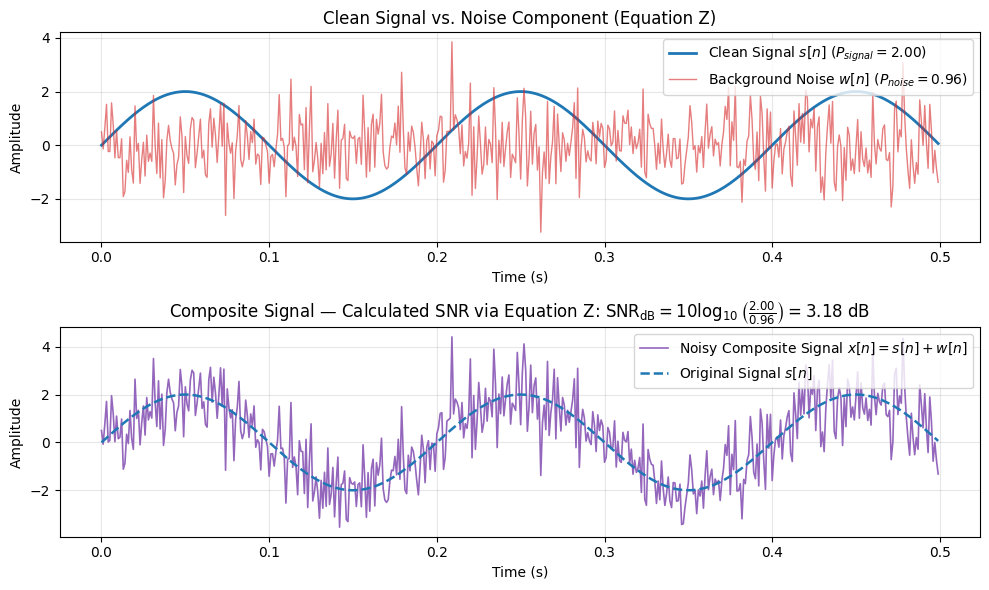

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Pure Signal & Noise Parameters
fs = 1000  # Sampling frequency (Hz)
N = 500  # Total sample count
n = np.arange(N)  # Sample index n
t = n / fs  # Continuous time mapping

# Generate clean sinusoidal signal
p_signal_target = 2.0  # Desired signal power
s = np.sqrt(2 * p_signal_target) * np.sin(2 * np.pi * 5 * t)

# Generate zero-mean Gaussian noise
np.random.seed(42)
noise_raw = np.random.normal(0, 1, N)

# Compute actual powers using discrete average power definition
P_signal = np.mean(s**2)  # P_signal term in Equation Z
P_noise = np.mean(noise_raw**2)  # P_noise term in Equation Z

# Add noise to signal to form noisy signal x[n]
x = s + noise_raw

# 2. Implement Equation Z: Signal-to-Noise Ratio (SNR) in dB
# Equation Z: SNR_dB = 10 * log10(P_signal / P_noise)
SNR_dB = 10 * np.log10(P_signal / P_noise)

# 3. Visualizing SNR (Equation Z)
plt.figure(figsize=(10, 6))

# Subplot 1: Clean Signal vs Unwanted Noise
plt.subplot(2, 1, 1)
plt.plot(
    t,
    s,
    label=f"Clean Signal $s[n]$ ($P_{{signal}} = {P_signal:.2f}$)",
    color="tab:blue",
    linewidth=2,
)
plt.plot(
    t,
    noise_raw,
    label=f"Background Noise $w[n]$ ($P_{{noise}} = {P_noise:.2f}$)",
    color="tab:red",
    linewidth=1,
    alpha=0.6,
)
plt.title(r"Clean Signal vs. Noise Component (Equation Z)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Composite Noisy Signal & Calculated SNR_dB
plt.subplot(2, 1, 2)
plt.plot(
    t,
    x,
    label=r"Noisy Composite Signal $x[n] = s[n] + w[n]$",
    color="tab:purple",
    linewidth=1.2,
)
plt.plot(
    t,
    s,
    label=r"Original Signal $s[n]$",
    color="tab:blue",
    linestyle="--",
    linewidth=1.8,
)

plt.title(
    f"Composite Signal — Calculated SNR via Equation Z: "
    rf"$\text{{SNR}}_{{\text{{dB}}}} = 10 \log_{{10}}\left(\frac{{{P_signal:.2f}}}{{{P_noise:.2f}}}\right) = {SNR_dB:.2f} \text{{ dB}}$"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

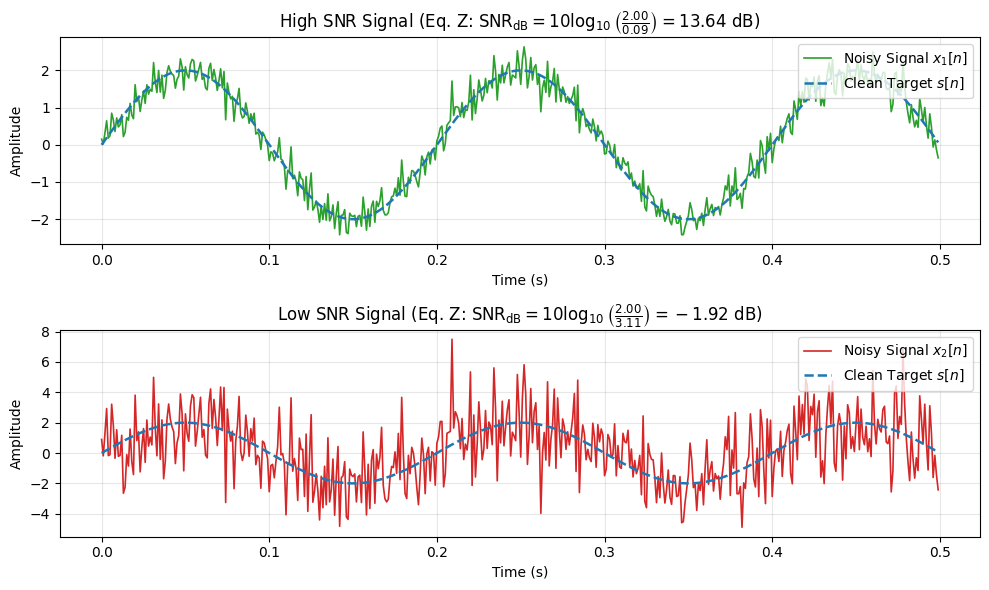

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Base Clean Signal & Time Axis
fs = 1000  # Sampling frequency (Hz)
N = 500  # Sample count
n = np.arange(N)
t = n / fs  # Continuous time mapping

# Clean signal: pure sine wave
p_signal_target = 2.0
s = np.sqrt(2 * p_signal_target) * np.sin(2 * np.pi * 5 * t)
P_signal = np.mean(s**2)  # P_signal for Equation Z

# Generate zero-mean Gaussian noise components for low and high noise scenarios
np.random.seed(42)
noise_raw = np.random.normal(0, 1, N)

# Noise Scenario 1: Low Noise (High SNR)
scale_low_noise = 0.3
noise_low = noise_raw * scale_low_noise
P_noise_low = np.mean(noise_low**2)  # P_noise term 1
x_high_snr = s + noise_low

# Equation Z for High SNR Signal
SNR_dB_high = 10 * np.log10(P_signal / P_noise_low)

# Noise Scenario 2: High Noise (Low SNR)
scale_high_noise = 1.8
noise_high = noise_raw * scale_high_noise
P_noise_high = np.mean(noise_high**2)  # P_noise term 2
x_low_snr = s + noise_high

# Equation Z for Low SNR Signal
SNR_dB_low = 10 * np.log10(P_signal / P_noise_high)

# 2. Visualizing Two Signals with Different SNR Values (Equation Z)
plt.figure(figsize=(10, 6))

# Subplot 1: Signal 1 — High SNR (Low Noise)
plt.subplot(2, 1, 1)
plt.plot(
    t,
    x_high_snr,
    label=r"Noisy Signal $x_1[n]$",
    color="tab:green",
    linewidth=1.2,
)
plt.plot(
    t,
    s,
    label=r"Clean Target $s[n]$",
    color="tab:blue",
    linestyle="--",
    linewidth=1.8,
)
plt.title(
    f"High SNR Signal (Eq. Z: $\\text{{SNR}}_{{\\text{{dB}}}} = 10 \\log_{{10}}\\left(\\frac{{{P_signal:.2f}}}{{{P_noise_low:.2f}}}\\right) = {SNR_dB_high:.2f} \\text{{ dB}}$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Signal 2 — Low SNR (High Noise)
plt.subplot(2, 1, 2)
plt.plot(
    t,
    x_low_snr,
    label=r"Noisy Signal $x_2[n]$",
    color="tab:red",
    linewidth=1.2,
)
plt.plot(
    t,
    s,
    label=r"Clean Target $s[n]$",
    color="tab:blue",
    linestyle="--",
    linewidth=1.8,
)
plt.title(
    f"Low SNR Signal (Eq. Z: $\\text{{SNR}}_{{\\text{{dB}}}} = 10 \\log_{{10}}\\left(\\frac{{{P_signal:.2f}}}{{{P_noise_high:.2f}}}\\right) = {SNR_dB_low:.2f} \\text{{ dB}}$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Level 3.8 – Dynamic Range

### Theory
Dynamic range measures the ratio between the strongest and weakest signals that can be represented without distortion or falling below the noise floor.

### Why Do We Need Dynamic Range?
* Audio recording
* Analog-to-Digital Converter (ADC) design
* Image sensors

---

## Mathematical Equation

### Equation AA
$$\text{DR} = 20 \log_{10} \left( \frac{A_{\max}}{A_{\min}} \right)$$

Where:
* $A_{\max}$ is the maximum peak signal amplitude before distortion (clipping)
* $A_{\min}$ is the minimum detectable signal amplitude (noise floor)
* $\text{DR}$ is the Dynamic Range expressed in decibels ($\text{dB}$)

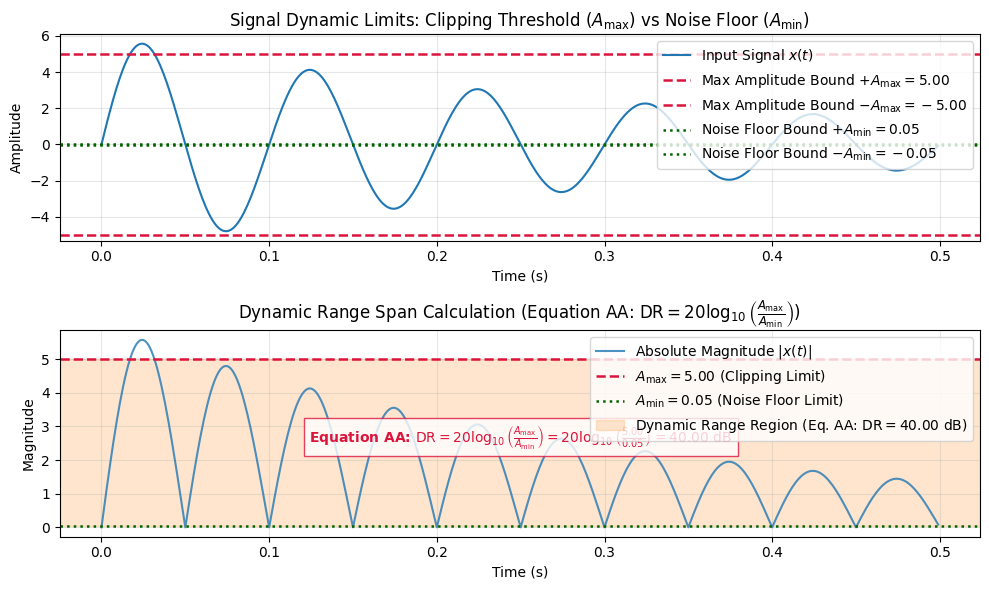

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Signal Parameters & Dynamic Range Limits
fs = 1000  # Sampling frequency (Hz)
N = 500  # Sample count
n = np.arange(N)
t = n / fs  # Continuous time mapping

# Define Maximum Peak Amplitude (A_max) and Minimum Detectable Amplitude / Noise Floor (A_min)
A_max = 5.0  # Maximum unclipped amplitude limit (A_max)
A_min = 0.05  # Noise floor threshold / minimum amplitude limit (A_min)

# Generate a signal with exponentially decaying amplitude to cross both limits
amplitude_envelope = A_max * 1.2 * np.exp(-3 * t)  # Starts above A_max
x = amplitude_envelope * np.sin(2 * np.pi * 10 * t)

# 2. Implement Equation AA: Dynamic Range Calculation
# Equation AA: DR = 20 * log10(A_max / A_min)
DR = 20 * np.log10(A_max / A_min)

# 3. Visualizing Dynamic Range Bounds & Equation AA
plt.figure(figsize=(10, 6))

# Subplot 1: Signal with A_max Clipping Bound & A_min Noise Floor Bound
plt.subplot(2, 1, 1)
plt.plot(t, x, label=r"Input Signal $x(t)$", color="tab:blue", linewidth=1.5)

# Plot upper/lower A_max bounds (Clipping threshold)
plt.axhline(
    A_max,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label=f"Max Amplitude Bound $+A_{{\\max}} = {A_max:.2f}$",
)
plt.axhline(
    -A_max,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label=f"Max Amplitude Bound $-A_{{\\max}} = -{A_max:.2f}$",
)

# Plot upper/lower A_min bounds (Noise floor threshold)
plt.axhline(
    A_min,
    color="darkgreen",
    linestyle=":",
    linewidth=1.8,
    label=f"Noise Floor Bound $+A_{{\\min}} = {A_min:.2f}$",
)
plt.axhline(
    -A_min,
    color="darkgreen",
    linestyle=":",
    linewidth=1.8,
    label=f"Noise Floor Bound $-A_{{\\min}} = -{A_min:.2f}$",
)

plt.title(
    r"Signal Dynamic Limits: Clipping Threshold ($A_{\max}$) vs Noise Floor ($A_{\min}$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Logarithmic Span Illustrating Dynamic Range (Equation AA)
plt.subplot(2, 1, 2)
abs_x = np.abs(x)

plt.plot(
    t, abs_x, label=r"Absolute Magnitude $|x(t)|$", color="tab:blue", alpha=0.8
)
plt.axhline(
    A_max,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label=f"$A_{{\\max}} = {A_max:.2f}$ (Clipping Limit)",
)
plt.axhline(
    A_min,
    color="darkgreen",
    linestyle=":",
    linewidth=1.8,
    label=f"$A_{{\\min}} = {A_min:.2f}$ (Noise Floor Limit)",
)

# Fill detectable range between A_min and A_max
plt.axhspan(
    A_min,
    A_max,
    color="tab:orange",
    alpha=0.2,
    label=f"Dynamic Range Region (Eq. AA: $\\text{{DR}} = {DR:.2f}$ dB)",
)

# Annotate Equation AA calculation on plot
plt.text(
    0.25,
    (A_max + A_min) / 2,
    f"Equation AA: $\\text{{DR}} = 20 \\log_{{10}}\\left(\\frac{{A_{{\\max}}}}{{A_{{\\min}}}}\\right) = 20 \\log_{{10}}\\left(\\frac{{{A_max:.2f}}}{{{A_min:.2f}}}\\right) = {DR:.2f} \\text{{ dB}}$",
    color="crimson",
    fontsize=10,
    fontweight="bold",
    ha="center",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="crimson"),
)

plt.title(
    r"Dynamic Range Span Calculation (Equation AA: $\text{DR} = 20 \log_{10} \left( \frac{A_{\max}}{A_{\min}} \right)$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Level 3.9 – DC Offset

### Theory
DC offset is the average value around which a signal oscillates. Ideally, many alternating current (AC) signals have a zero DC offset, meaning they are centered at zero amplitude.

### Why Do We Need DC Offset?
* Sensor calibration
* Audio preprocessing
* Biomedical signals

---

## Mathematical Equation

### Equation AB
$$\text{DC} = \frac{1}{N} \sum_{n=0}^{N-1} x[n]$$

Where:
* $x[n]$ is the discrete-time input signal
* $N$ is the total number of samples
* $\text{DC}$ is the direct current component (mean value) of the signal

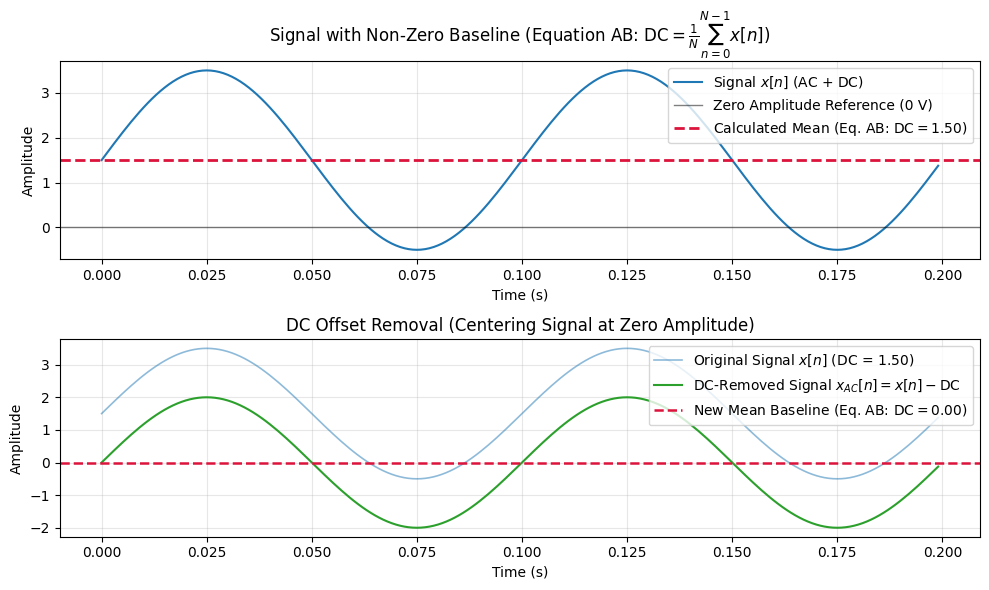

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Discrete-Time Signal x[n] with DC Offset
N = 200  # Total sample count N
n = np.arange(N)  # Sample index n
t = n / 1000.0  # Continuous time mapping

# Pure AC signal centered around zero
ac_component = 2.0 * np.sin(2 * np.pi * 10 * t)

# Add a DC offset constant
dc_shift = 1.5  # True DC Offset value
x = ac_component + dc_shift  # x[n] = AC + DC

# 2. Implement Equation AB: DC Offset Calculation
# Equation AB: DC = (1/N) * sum(x[n])
DC_calculated = (1 / N) * np.sum(x)  # Calculated DC offset via Equation AB

# Demanded AC signal after DC offset removal
x_ac_only = x - DC_calculated

# 3. Visualizing DC Offset (Equation AB)
plt.figure(figsize=(10, 6))

# Subplot 1: Original Signal with Shifted Baseline (DC Offset)
plt.subplot(2, 1, 1)
plt.plot(
    t,
    x,
    label=r"Signal $x[n]$ (AC + DC)",
    color="tab:blue",
    linewidth=1.5,
)
plt.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=1.0,
    alpha=0.5,
    label="Zero Amplitude Reference (0 V)",
)
plt.axhline(
    DC_calculated,
    color="crimson",
    linestyle="--",
    linewidth=2.0,
    label=f"Calculated Mean (Eq. AB: $\\text{{DC}} = {DC_calculated:.2f}$)",
)
plt.title(
    r"Signal with Non-Zero Baseline (Equation AB: $\text{DC} = \frac{1}{N} \sum_{n=0}^{N-1} x[n]$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Comparison of Original Signal vs DC-Removed Pure AC Signal
plt.subplot(2, 1, 2)
plt.plot(
    t,
    x,
    label=f"Original Signal $x[n]$ (DC = {DC_calculated:.2f})",
    color="tab:blue",
    alpha=0.5,
    linewidth=1.2,
)
plt.plot(
    t,
    x_ac_only,
    label=r"DC-Removed Signal $x_{AC}[n] = x[n] - \text{DC}$",
    color="tab:green",
    linewidth=1.5,
)
plt.axhline(
    0,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label="New Mean Baseline (Eq. AB: $\\text{DC} = 0.00$)",
)
plt.title(r"DC Offset Removal (Centering Signal at Zero Amplitude)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Level 3.10 – Peak-to-Peak Amplitude

### Theory
Peak-to-peak amplitude measures the total vertical excursion of a signal from its absolute minimum value to its absolute maximum value.

### Why Do We Need Peak-to-Peak?
* Oscilloscope measurements
* Analog-to-Digital Converter (ADC) input range
* Signal quality checks

---

## Mathematical Equation

### Equation AC
$$V_{pp} = x_{\max} - x_{\min}$$

Where:
* $x_{\max}$ is the maximum instantaneous signal value
* $x_{\min}$ is the minimum instantaneous signal value
* $V_{pp}$ is the total peak-to-peak amplitude

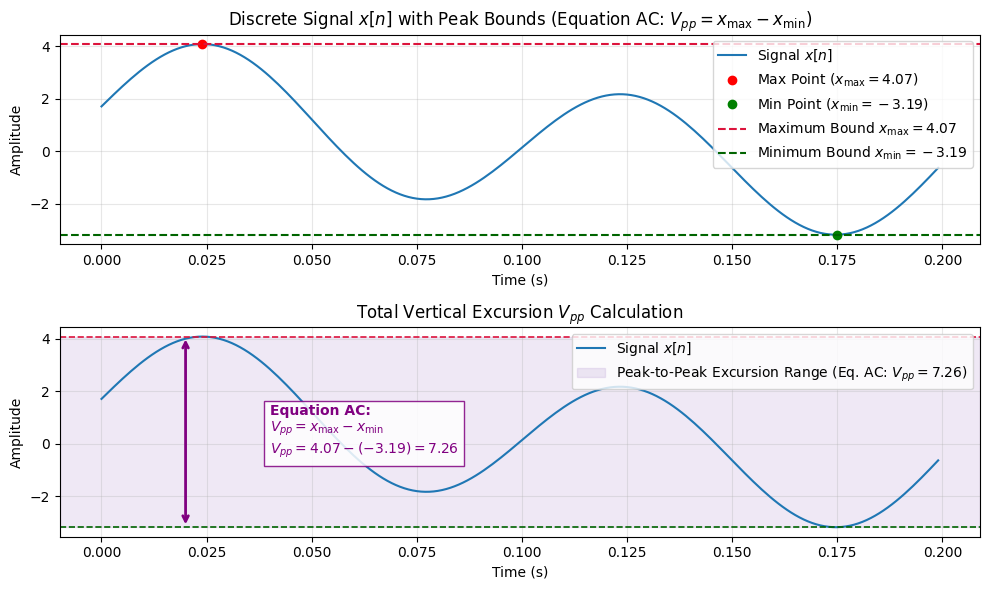

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Discrete-Time Signal x[n]
N = 200  # Total sample count N
n = np.arange(N)  # Sample index n
t = n / 1000.0  # Continuous time mapping

# Generate a complex oscillating signal with offset
x = 2.5 * np.sin(2 * np.pi * 10 * t) + 1.2 * np.cos(2 * np.pi * 3 * t) + 0.5

# 2. Implement Equation AC: Peak-to-Peak Amplitude Calculation
# Equation AC: V_pp = x_max - x_min
x_max = np.max(x)  # Maximum value x_max
x_min = np.min(x)  # Minimum value x_min
V_pp = x_max - x_min  # Peak-to-Peak Amplitude calculated via Equation AC

# Identify sample indices for visual marker points
n_max = np.argmax(x)
n_min = np.argmin(x)
t_max = t[n_max]
t_min = t[n_min]

# 3. Visualizing Peak-to-Peak Amplitude (Equation AC)
plt.figure(figsize=(10, 6))

# Subplot 1: Signal with Max and Min Threshold Bounds
plt.subplot(2, 1, 1)
plt.plot(t, x, label=r"Signal $x[n]$", color="tab:blue", linewidth=1.5)
plt.plot(t_max, x_max, "ro", label=f"Max Point ($x_{{\\max}} = {x_max:.2f}$)")
plt.plot(t_min, x_min, "go", label=f"Min Point ($x_{{\\min}} = {x_min:.2f}$)")

plt.axhline(
    x_max,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Maximum Bound $x_{{\\max}} = {x_max:.2f}$",
)
plt.axhline(
    x_min,
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
    label=f"Minimum Bound $x_{{\\min}} = {x_min:.2f}$",
)

plt.title(
    r"Discrete Signal $x[n]$ with Peak Bounds (Equation AC: $V_{pp} = x_{\max} - x_{\min}$)"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

# Subplot 2: Annotating the Total Excursion V_pp
plt.subplot(2, 1, 2)
plt.plot(t, x, label=r"Signal $x[n]$", color="tab:blue", linewidth=1.5)

plt.axhline(x_max, color="crimson", linestyle="--", linewidth=1.2)
plt.axhline(x_min, color="darkgreen", linestyle="--", linewidth=1.2)

# Span highlighting total peak-to-peak excursion range
plt.axhspan(
    x_min,
    x_max,
    color="tab:purple",
    alpha=0.15,
    label=f"Peak-to-Peak Excursion Range (Eq. AC: $V_{{pp}} = {V_pp:.2f}$)",
)

# Annotate Equation AC on the plot
t_mid = (t_max + t_min) / 2
plt.annotate(
    "",
    xy=(0.02, x_min),
    xytext=(0.02, x_max),
    arrowprops=dict(arrowstyle="<->", color="purple", lw=2),
)
plt.text(
    0.04,
    (x_max + x_min) / 2,
    f"Equation AC:\n$V_{{pp}} = x_{{\\max}} - x_{{\\min}}$\n$V_{{pp}} = {x_max:.2f} - ({x_min:.2f}) = {V_pp:.2f}$",
    color="purple",
    fontsize=10,
    fontweight="bold",
    va="center",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="purple"),
)

plt.title(r"Total Vertical Excursion $V_{pp}$ Calculation")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()